### Import packages

In [2]:

import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
from xgboost import plot_importance
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import plot_tree
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import to_graphviz
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.feature_selection import RFECV,SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.getcwd()
os.chdir('/content/drive/MyDrive/GTU/DSAN5300/dsan5300_group1_final_project/')

## BNPL1 - Full data

### Data preprocessing

1. LOAD DATA

In [63]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_59702/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [64]:
# drop unnessary columns and unique columns in 2024 data
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C']).loc[-data['BNPL1'].isna()].isna().sum()

,0
weight,0
BNPL1,0
EF3_a,0
EF3_b,0
EF3_c,0
EF3_d,0
EF3_e,0
EF3_f,0
EF3_g,0
EF3_h,0


comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

Drop nas

In [65]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])
data_cleaned.loc[-data_cleaned['BNPL1'].isna()].isna().sum()

# independent variables
X = data_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']


Check X columns

In [ ]:
pd.DataFrame([(c,X[c].unique()) for c in X.columns], columns=['column', 'values'])

,column,values
0,EF3_a,"[Yes, No]"
1,EF3_b,"[No, Yes]"
2,EF3_c,"[No, Yes]"
3,EF3_d,"[No, Yes]"
4,EF3_e,"[No, Yes]"
5,EF3_f,"[No, Yes]"
6,EF3_g,"[No, Yes]"
7,EF3_h,"[No, Yes]"
8,I20,"[The same as your income, More than your incom..."
9,ppfs0596,"[$50,000 - $99,999, Not sure, Under $50,000, n..."


Data transformation

In [66]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [68]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }

# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3,5],
    'min_child_weight': [5, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0.1, 0.5, 1]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])

scoring = {
    'f1_class1': make_scorer(f1_score, pos_label=1),
    'recall_class1': make_scorer(recall_score, pos_label=1),
    'precision_class1': make_scorer(precision_score, pos_label=1)
}

# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="auc",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='roc_auc',   # AUC metric
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)

# Prediction
y_pred = grid_search.predict(X_test)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


Optimal model and parameters from cv

In [10]:
# best auc from grid search
auc_score = grid_search.best_score_
# optimial paramters
best_parameters = grid_search.best_params_

print('Best training AUC:', auc_score)
print('Best parameters:', best_parameters)

Best training AUC: 0.8489205866376714
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}


Predict using test data and best paramters

In [69]:
# 1. predict
y_probs = grid_search.predict_proba(X_test)[:, 1]

# 2. Calculate Test AUC and f1
test_auc = roc_auc_score(y_test, y_probs)
test_f1 = f1_score(y_test, y_pred)
print(f'Test AUC: {test_auc:.4f}')
print(f'Test F1: {test_f1:.4f}')


Test AUC: 0.7630
Test F1: 0.3659


Confusion matrix and test accuracies

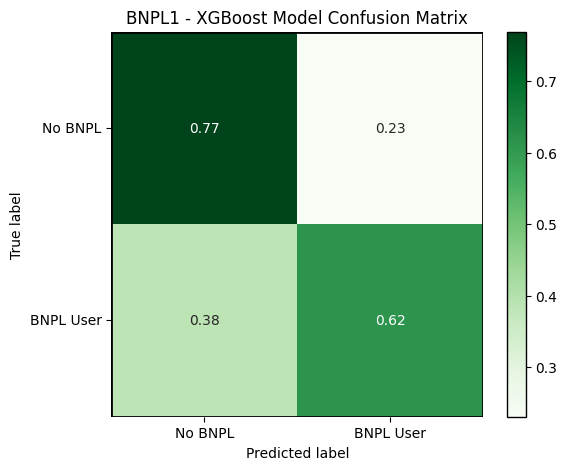

In [70]:

cm_xgboost_BNPL1 = confusion_matrix(y_test, y_pred, normalize='true')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_xgboost_BNPL1,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['No BNPL', 'BNPL User'],
    yticklabels=['No BNPL', 'BNPL User']
)

plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL1 - XGBoost Model Confusion Matrix")
plt.show()

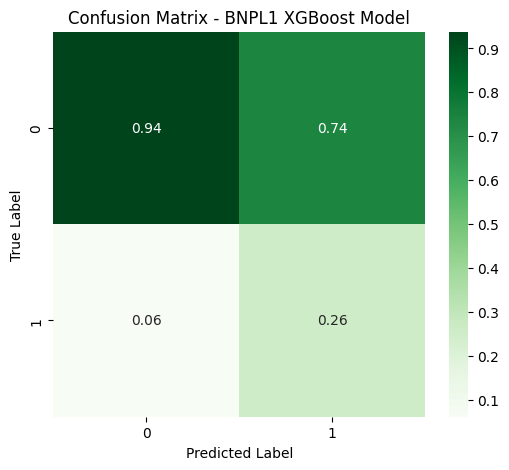

In [72]:
# cm
cm_xgboost_BNPL1 = confusion_matrix(y_test, y_pred, normalize='pred')

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgboost_BNPL1,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 XGBoost Model")
plt.show()


### Display tree

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


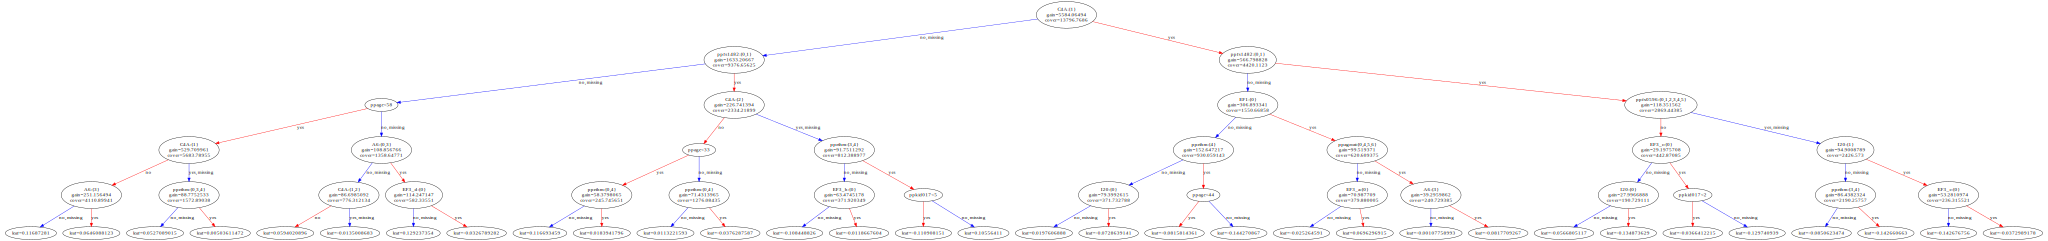

In [ ]:
# best model
best_model_BNPL1 = grid_search.best_estimator_

tree_graph_BNPL1 = to_graphviz(best_model_BNPL1, num_trees=0)
tree_graph_BNPL1

In [ ]:
tree_graph_BNPL1.render('img/tree_graph_BNPL1', format='png', view=False)

'img/tree_graph_BNPL1.png'

### Feature importance

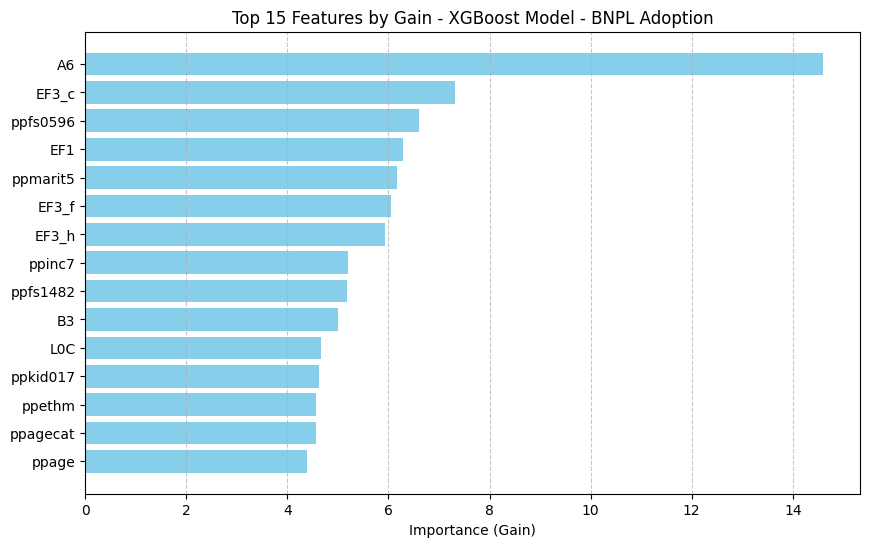

<Figure size 640x480 with 0 Axes>

In [27]:
# Access the best model directly from the grid search
best_xgb_model_BNPL1 = grid_search.best_estimator_

# Get Gain-based importance
importance_scores_BNPL1 = best_xgb_model_BNPL1.get_booster().get_score(importance_type='gain')

# Sort for plotting
sorted_importance_BNPL1 = dict(sorted(importance_scores_BNPL1.items(), key=lambda item: item[1], reverse=True)[:15])

plt.figure(figsize=(10, 6))
plt.barh(list(sorted_importance_BNPL1.keys())[::-1], list(sorted_importance_BNPL1.values())[::-1], color='skyblue')
plt.xlabel("Importance (Gain)")
plt.title("Top 15 Features by Gain - XGBoost Model - BNPL Adoption")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
plt.savefig('img/feature_importance_XGBoost_BNPL1.png', dpi=300, bbox_inches='tight')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.getcwd()
os.chdir('/content/drive/MyDrive/GTU/DSAN5300/dsan5300_group1_final_project/')

### Rebuild model with OHE columns for SHAP

In [28]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_11174/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [29]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [30]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [31]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017"]

scaler = StandardScaler()

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [32]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])

In [33]:
pd.DataFrame([(c,data_cleaned[c].unique()) for c in data_cleaned.columns], columns=['column', 'values'])

,column,values
0,weight,"[0.5404, 0.7613, 0.789, 0.5585, 0.8362, 0.7032..."
1,BNPL1,"[0, 1]"
2,EF3_a,"[1, 0]"
3,EF3_b,"[0, 1]"
4,EF3_c,"[0, 1]"
...,...,...
75,L0C_1,"[0, 1]"
76,L0C_2,"[1, 0]"
77,L0C_3,"[0, 1]"
78,L0C_4,"[0, 1]"


In [34]:
# independent variables
X = data_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']

In [35]:
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test_aug["weight"].values
X_test_res = X_test_aug.drop(columns=["weight"])


In [36]:

# Build model
xgb = XGBClassifier(n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=5,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method="hist",
    eval_metric="auc",
    enable_categorical=True,
    random_state=42
    )

xgb_fit = xgb.fit(X_train_res, y_train_res, sample_weight=w_train_res)

# Prediction
y_pred = xgb_fit.predict(X_test_res)

### SHAP

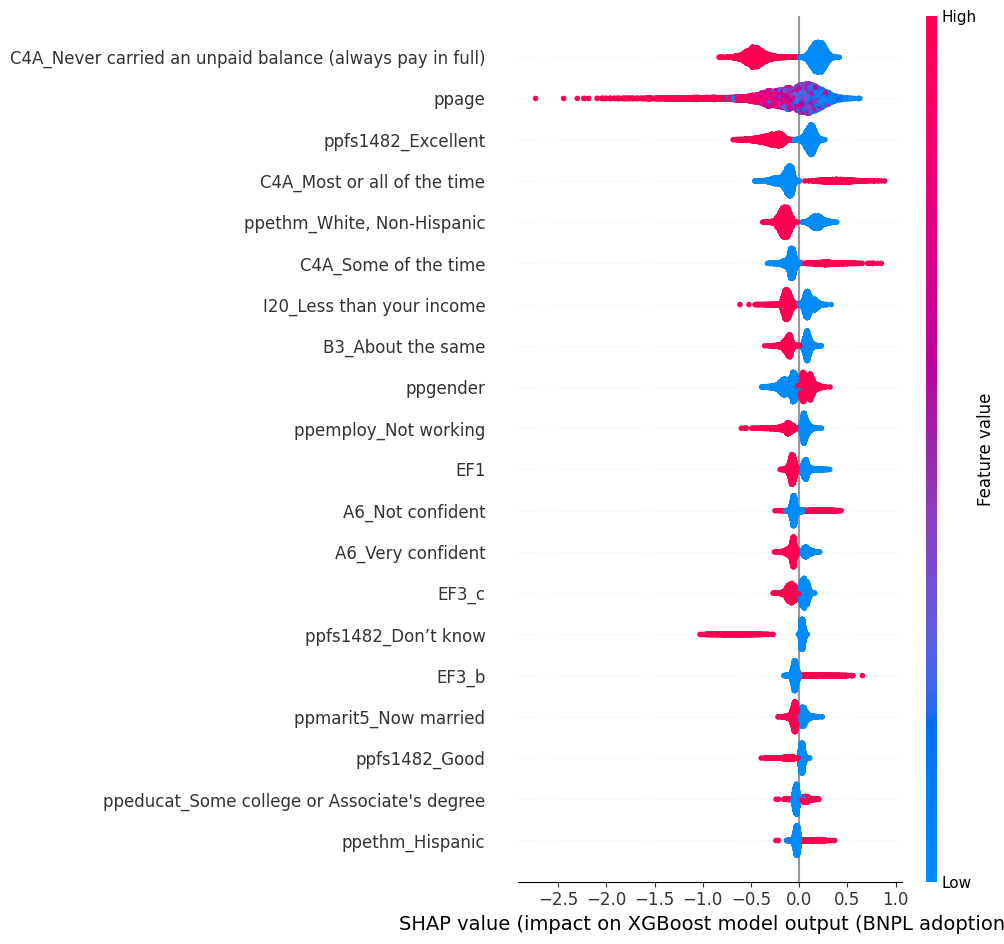

<Figure size 640x480 with 0 Axes>

In [37]:
explainer = shap.TreeExplainer(xgb_fit)
shap_values = explainer.shap_values(X_test_res)

plt.figure(figsize=(35, 12))
shap.summary_plot(shap_values, X_test_res, show=False)

plt.subplots_adjust(left=0.35, right=0.95)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("SHAP value (impact on XGBoost model output (BNPL adoption))", fontsize=14)

plt.show()
# save
plt.savefig('img/shap_BNPL1.png', dpi=300, bbox_inches='tight')

## BNPL3 - full data

### Data preprocessing

In [73]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_59702/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [74]:
# check nas
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
               'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C']).loc[-data['BNPL3'].isna()].isna().sum()

,0
weight,0
BNPL3,0
EF3_a,0
EF3_b,0
EF3_c,0
EF3_d,0
EF3_e,0
EF3_f,0
EF3_g,0
EF3_h,0


comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

Drop nas

In [75]:
# drop columns
data_cleaned = data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])

In [57]:
len(data_cleaned)

863

In [76]:
data_cleaned = data_cleaned.dropna()

In [77]:
# independent variables
X = data_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data_cleaned['BNPL3']

# weights
weights = data_cleaned['weight']

Data tranformation

In [78]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [79]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }
counts = y_train.value_counts()
ratio = counts[0] / counts[1]
# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.01, 0.03],
    'max_depth': [5, 7, 9],
    'min_child_weight': [1, 2],
    'scale_pos_weight': [1, ratio, ratio *1.5],
    'reg_alpha': [0.1, 1],          # L1 Regularization
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])


# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="logloss",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='average_precision',
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.01, 0.03],
                         'max_depth': [5, 7, 9], 'min_child_weight': [1, 2],
                         'n_estimators': [200, 500], 'reg_alpha': [0.1, 1],
                         'scale_pos_weight': [1, np.float64(4.036496350364963),
                                              np.float64(6.054744525547445)],
                         'subsample': [0.8]},
             scoring='average_precision', verbose=2)

Optimal model and parameters

In [21]:
# best auc from grid search
auc_score = grid_search.best_score_
# optimial paramters
best_parameters = grid_search.best_params_

print('Best training AUC:', auc_score)
print('Best parameters:', best_parameters)

Best training AUC: 0.9880679136225415
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'scale_pos_weight': np.float64(6.054744525547445), 'subsample': 0.8}


Predict using test data and best parameters

In [80]:
# 1. predict
y_probs = grid_search.predict_proba(X_test)[:, 1]
# instead of 0.5, use 0.3 as treshold to predict as class1 to boost Recall
y_pred_custom = (y_probs >= 0.3).astype(int)
# 2. Calculate Test AUC
test_auc = roc_auc_score(y_test, y_pred_custom)

print(f'Test AUC: {test_auc:.4f}')

Test AUC: 0.6659


Confusion matrix and test accuracies

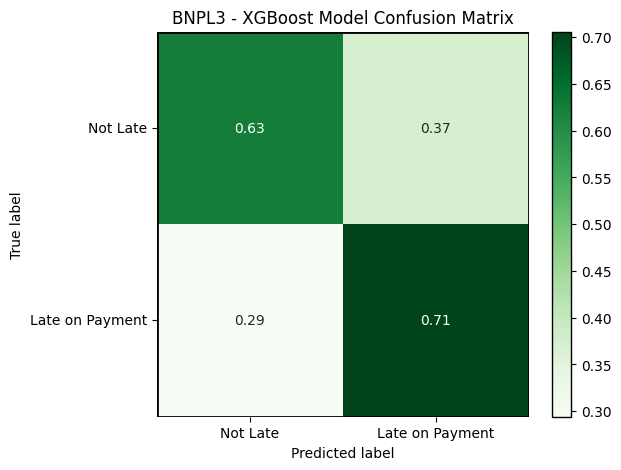

In [81]:

cm_xgboost_BNPL3 = confusion_matrix(y_test, y_pred_custom, normalize='true')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_xgboost_BNPL3,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['Not Late', 'Late on Payment'],
    yticklabels=['Not Late', 'Late on Payment']
)
plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL3 - XGBoost Model Confusion Matrix")
plt.show()

Best Parmaters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'scale_pos_weight': np.float64(6.054744525547445), 'subsample': 0.8}
AUC: 0.9880679136225415


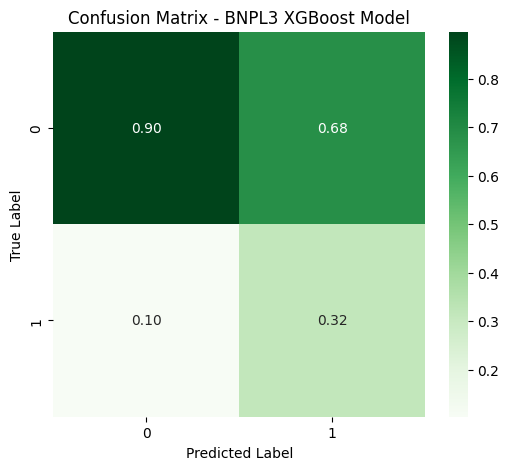

In [82]:
cm = confusion_matrix(y_test, y_pred_custom, normalize='pred')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 XGBoost Model")
plt.show()


### Display tree

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


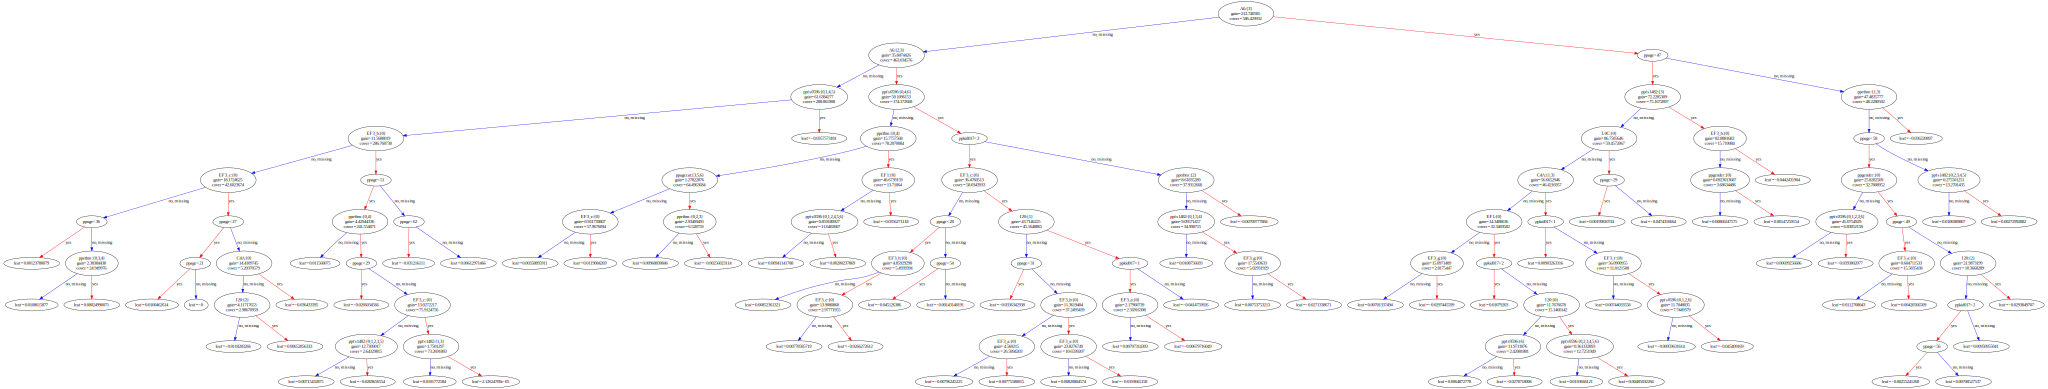

In [ ]:
# best model
best_model_BNPL3 = grid_search.best_estimator_

graph_BNPL3 = to_graphviz(best_model_BNPL3, num_trees=0)
graph_BNPL3

In [ ]:
graph_BNPL3.render('img/tree_graph_BNPL3', format='png', view=False)

'img/tree_graph_BNPL3.png'

### Feature importance

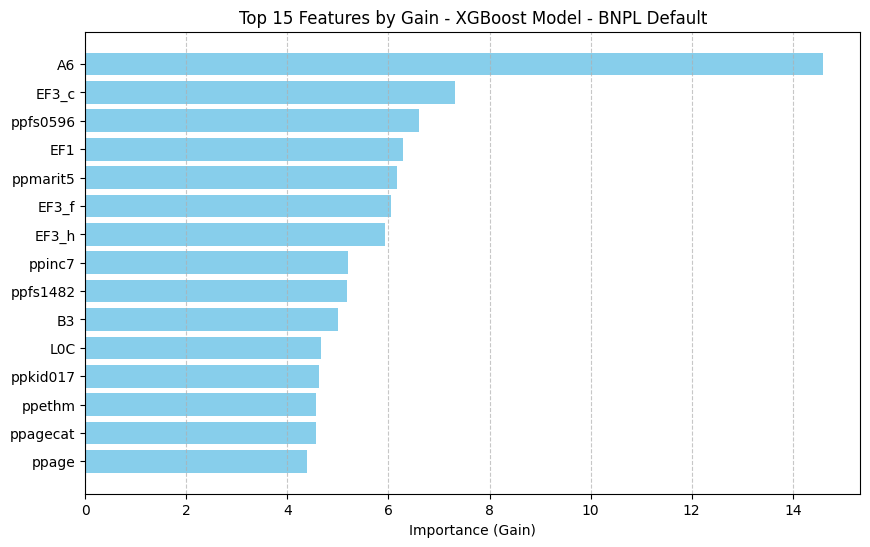

<Figure size 640x480 with 0 Axes>

In [26]:
# Get best model directly from the grid search
best_xgb_model = grid_search.best_estimator_

# Get Gain-based importance
importance_scores = best_xgb_model.get_booster().get_score(importance_type='gain')

# Sort for plotting
sorted_importance = dict(sorted(importance_scores.items(), key=lambda item: item[1], reverse=True)[:15])

plt.figure(figsize=(10, 6))
plt.barh(list(sorted_importance.keys())[::-1], list(sorted_importance.values())[::-1], color='skyblue')
plt.xlabel("Importance (Gain)")
plt.title("Top 15 Features by Gain - XGBoost Model - BNPL Default")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
plt.savefig('img/feature_importance_XGBoost_BNPL3.png', dpi=300, bbox_inches='tight')

### Rebuild model with OHE to graph SHAP

In [38]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_11174/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [39]:
# drop na
data = data.loc[-data['BNPL3'].isna()]

In [40]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL3']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [41]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [42]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data[c] = data[c].map(map_cols3)

In [43]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [44]:
# drop columns
data_cleaned = data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])

In [45]:
pd.DataFrame([(c,data_cleaned[c].unique()) for c in data_cleaned.columns], columns=['column', 'values'])


,column,values
0,weight,"[0.3553, 0.6546, 1.1176, 0.728, 0.9102, 0.9073..."
1,BNPL3,"[0, 1]"
2,EF3_a,"[0, 1]"
3,EF3_b,"[1, 0]"
4,EF3_c,"[1, 0]"
...,...,...
75,L0C_1,"[0, 1]"
76,L0C_2,"[0, 1]"
77,L0C_3,"[0, 1]"
78,L0C_4,"[0, 1]"


In [46]:

# independent variables
X = data_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data_cleaned['BNPL3']

# weights
weights = data_cleaned['weight']


# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)


# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test_aug["weight"].values
X_test_res = X_test_aug.drop(columns=["weight"])



In [47]:


# Build model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=9,
    min_child_weight=1,
    reg_alpha=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method="hist",
    eval_metric="auc",
    scale_pos_weight= 6.054744525547445,
    enable_categorical=True,
    random_state=42
    )
xgb_fit = xgb.fit(X_train_res, y_train_res, sample_weight=w_train_res)

# Prediction
y_pred = xgb_fit.predict(X_test_res)

### SHAP

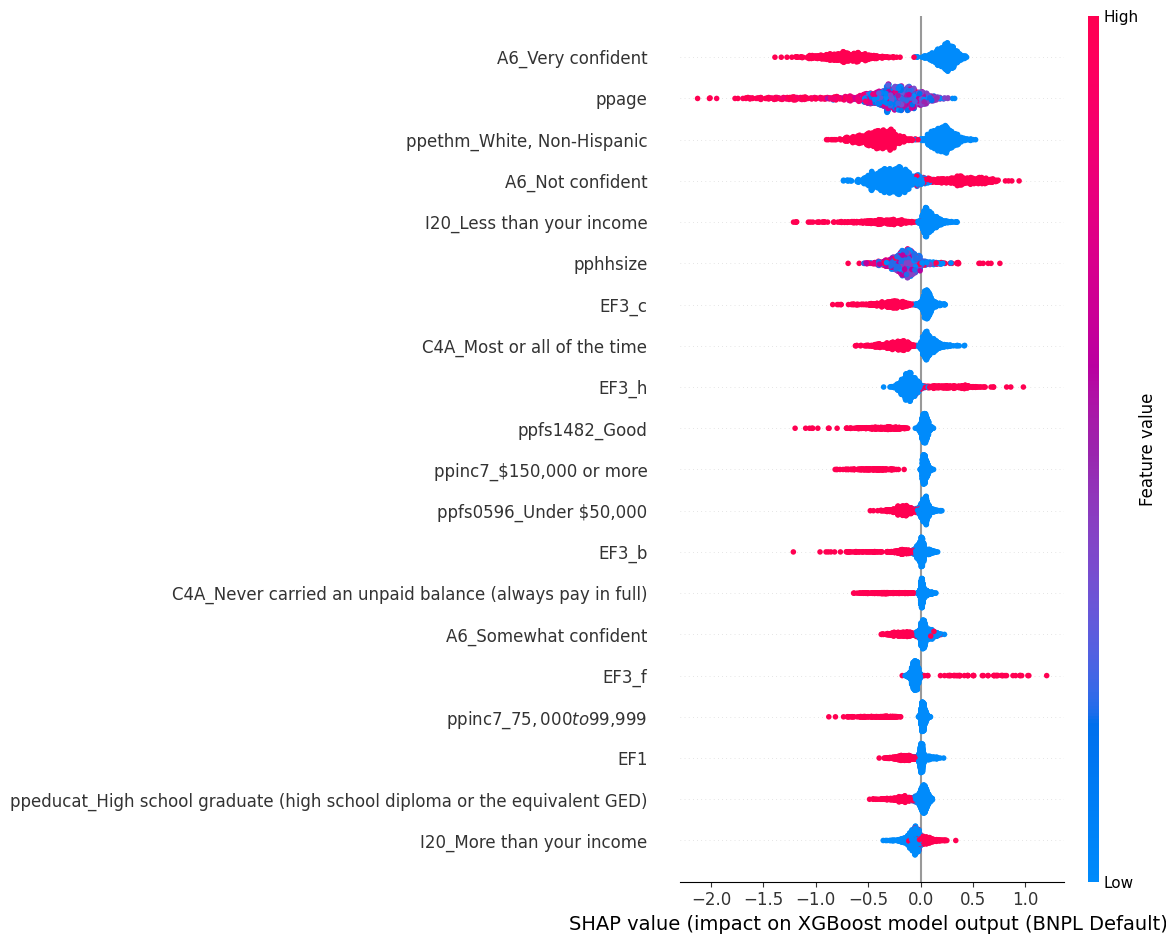

<Figure size 640x480 with 0 Axes>

In [48]:
explainer = shap.TreeExplainer(xgb_fit)
shap_values = explainer.shap_values(X_test_res)

plt.figure(figsize=(35, 12))
shap.summary_plot(shap_values, X_test_res, show=False)

plt.subplots_adjust(left=0.35, right=0.95)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("SHAP value (impact on XGBoost model output (BNPL Default))", fontsize=14)

plt.show()

# save
plt.savefig('img/shap_BNPL3.png', dpi=300, bbox_inches='tight')

## BNPL1 - 2024 data

### Data pre-processing

In [ ]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/tmp/ipykernel_4129/2448053278.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [ ]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data_2024[c] = data_2024[c].map(map_cols1)

/tmp/ipykernel_4129/1665977338.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024[c] = data_2024[c].map(map_cols1)
/tmp/ipykernel_4129/1665977338.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024[c] = data_2024[c].map(map_cols1)
/tmp/ipykernel_4129/1665977338.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [ ]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data_2024[c], prefix=c).astype(int)

data_2024 = pd.concat([data_2024, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [ ]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data_2024[c] = data_2024[c].map(map_cols3)

In [ ]:
# drop columns
data2024_cleaned = data_2024.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                      'I41_c','I41_e', 'SL6', 'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C'])

In [ ]:
# drop nas
data_2024_cleaned = data2024_cleaned.dropna()

In [ ]:
# independent variables
X = data_2024_cleaned.drop(columns=['BNPL1'])
# target variable
y = data_2024_cleaned['BNPL1']

# weights
weights = data_2024_cleaned['weight']

In [ ]:
# train, test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# resampling train fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test["weight"].values
X_test_res = X_test.drop(columns=["weight"])


In [ ]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_test_res[numeric_cols] = scaler.transform(X_test_res[numeric_cols])

In [ ]:
# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test["weight"].values
X_test = X_test.drop(columns=["weight"])


### XGBoost

Modeling

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }
counts = y_train.value_counts()
ratio = counts[0] / counts[1]
# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'scale_pos_weight': [1, ratio, ratio *1.5],
    'reg_alpha': [0.1, 1],          # L1 Regularization
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="logloss",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='f1',
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'min_child_weight': [1, 5],
                         'n_estimators': [100, 200, 500], 'reg_alpha': [0.1, 1],
                         'scale_pos_weight': [1, np.float64(3.4615384615384617),
                                              np.float64(5.1923076923076925)],
                         'subsample': [0.8]},
             scoring='f1', verbose=2)

Best Parmaters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
AUC: 0.8994165618818257


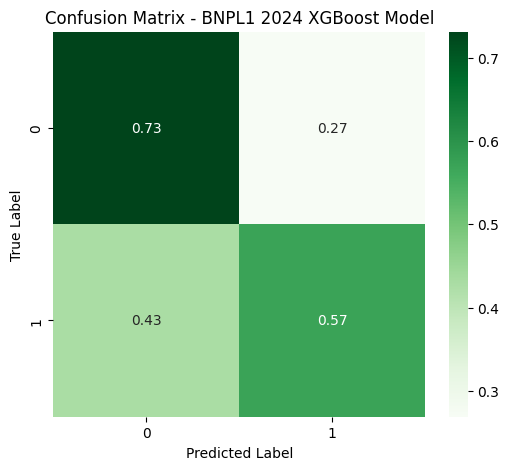

In [ ]:
# Get probabilities for Class 1
y_probs = grid_search.predict_proba(X_test)[:, 1]

# Lower threshold to improve Recall for Class 1
threshold = 0.35
y_pred_adjusted = (y_probs >= threshold).astype(int)

# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred_adjusted, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 2024 XGBoost Model")
plt.show()


### SHAP

In [ ]:

# independent variables
X = data2024_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data2024_cleaned['BNPL1']

# weights
weights = data2024_cleaned['weight']


# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)


# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test_aug["weight"].values
X_test_res = X_test_aug.drop(columns=["weight"])



In [ ]:
# Build optimal model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    reg_alpha=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method="hist",
    eval_metric="auc",
    enable_categorical=True,
    random_state=42
    )
xgb_fit = xgb.fit(X_train_res, y_train_res, sample_weight=w_train_res)

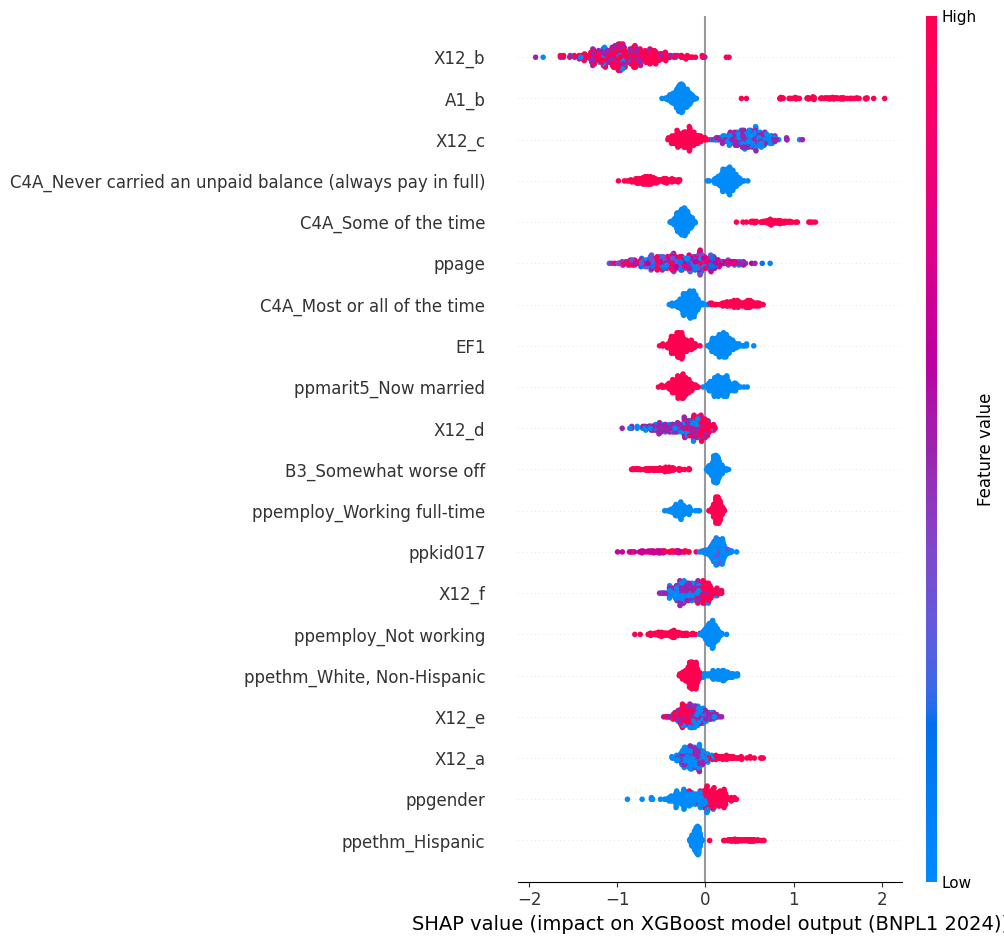

In [ ]:
# SHAP plot
explainer = shap.TreeExplainer(xgb_fit)
shap_values = explainer.shap_values(X_test_res)

plt.figure(figsize=(35, 12))
shap.summary_plot(shap_values, X_test_res, show=False)

plt.subplots_adjust(left=0.35, right=0.95)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("SHAP value (impact on XGBoost model output (BNPL1 2024))", fontsize=14)

plt.show()

# save
#plt.savefig('img/shap_BNPL1_2024.png', dpi=300, bbox_inches='tight')

## BNPL3 - 2024 data

### Data pre-processing

In [ ]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/tmp/ipykernel_2370/2448053278.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [ ]:
# check nas
pd.set_option('display.max_rows', None)

data_2024_cleaned = data_2024.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year','SL6','ppfs0596','I41_e','I41_c','SL6','ppfs0596'
            ])

In [ ]:
data_2024_cleaned= data_2024_cleaned.dropna()

In [ ]:
# independent variables
X = data_2024_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data_2024_cleaned['BNPL3']

# weights
weights = data_2024_cleaned['weight']


Data transformation

In [ ]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [ ]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }
counts = y_train.value_counts()
ratio = counts[0] / counts[1]
# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'scale_pos_weight': [1, ratio, ratio *1.5],
    'reg_alpha': [0.1, 1],          # L1 Regularization
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])


# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="logloss",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='f1',
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=2.1904761904761907, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=2.1904761904761907, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=2.1904761904761907, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_child_weight': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

Evaluation results

Best Parmaters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
AUC: 0.8704827457243246


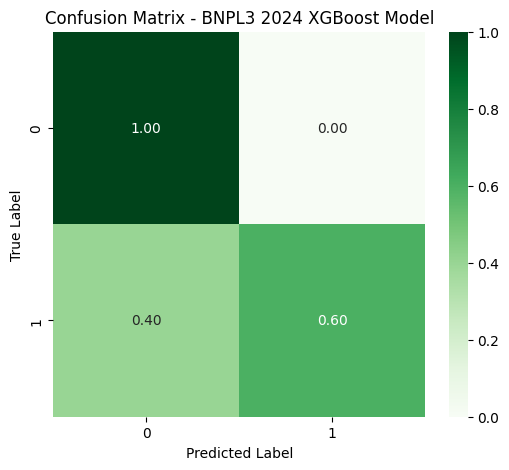

In [ ]:
# Get probabilities for Class 1
y_probs = grid_search.predict_proba(X_test)[:, 1]

# Lower threshold to improve Recall for Class 1
threshold = 0.35
y_pred_adjusted = (y_probs >= threshold).astype(int)

# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred_adjusted, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 2024 XGBoost Model")
plt.show()


Graph tree

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


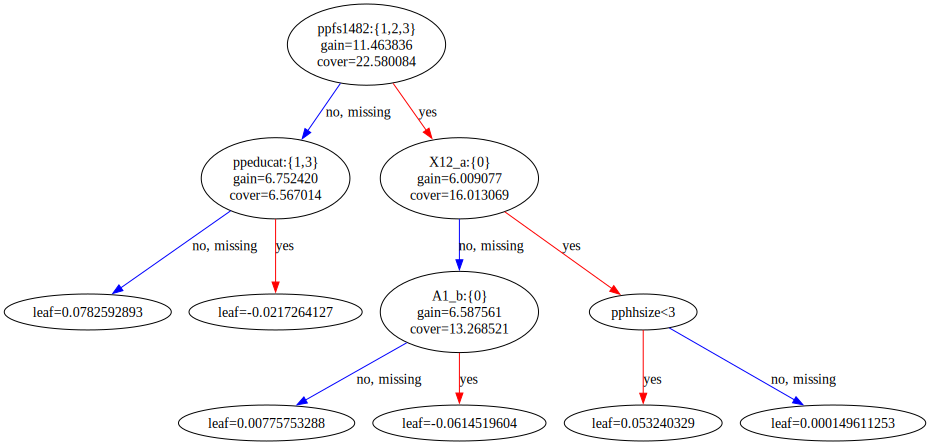

In [ ]:
# best model
best_model_BNPL3_2024 = grid_search.best_estimator_

graph_BNPL3_2024 = to_graphviz(best_model_BNPL3_2024, num_trees=0)
graph_BNPL3_2024

### SHAP

In [ ]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/tmp/ipykernel_2370/2448053278.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [ ]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL3']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data_2024[c] = data_2024[c].map(map_cols1)

/tmp/ipykernel_2370/1784457554.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024[c] = data_2024[c].map(map_cols1)
/tmp/ipykernel_2370/1784457554.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024[c] = data_2024[c].map(map_cols1)
/tmp/ipykernel_2370/1784457554.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [ ]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data_2024[c], prefix=c).astype(int)

data_2024 = pd.concat([data_2024, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [ ]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data_2024[c] = data_2024[c].map(map_cols3)

In [ ]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

data_2024[numeric_cols] = scaler.fit_transform(data_2024[numeric_cols])

In [ ]:
data_2024 = data_2024.loc[-data_2024['BNPL3'].isna()]

In [ ]:
# drop columns
data2024_cleaned = data_2024.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                      'I41_e', 'SL6', 'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C'])

In [ ]:
data2024_cleaned = data2024_cleaned.dropna()

In [ ]:
data2024_cleaned.isna().sum()

,0
weight,0
BNPL3,0
EF3_a,0
EF3_b,0
EF3_c,0
EF3_d,0
EF3_e,0
EF3_f,0
EF3_g,0
EF3_h,0


In [ ]:

# independent variables
X = data2024_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data2024_cleaned['BNPL3']

# weights
weights = data2024_cleaned['weight']


# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)


# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test_aug["weight"].values
X_test_res = X_test_aug.drop(columns=["weight"])



In [ ]:
# Build model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1,
    reg_alpha=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method="hist",
    eval_metric="auc",
    enable_categorical=True,
    random_state=42
    )
xgb_fit = xgb.fit(X_train_res, y_train_res, sample_weight=w_train_res)

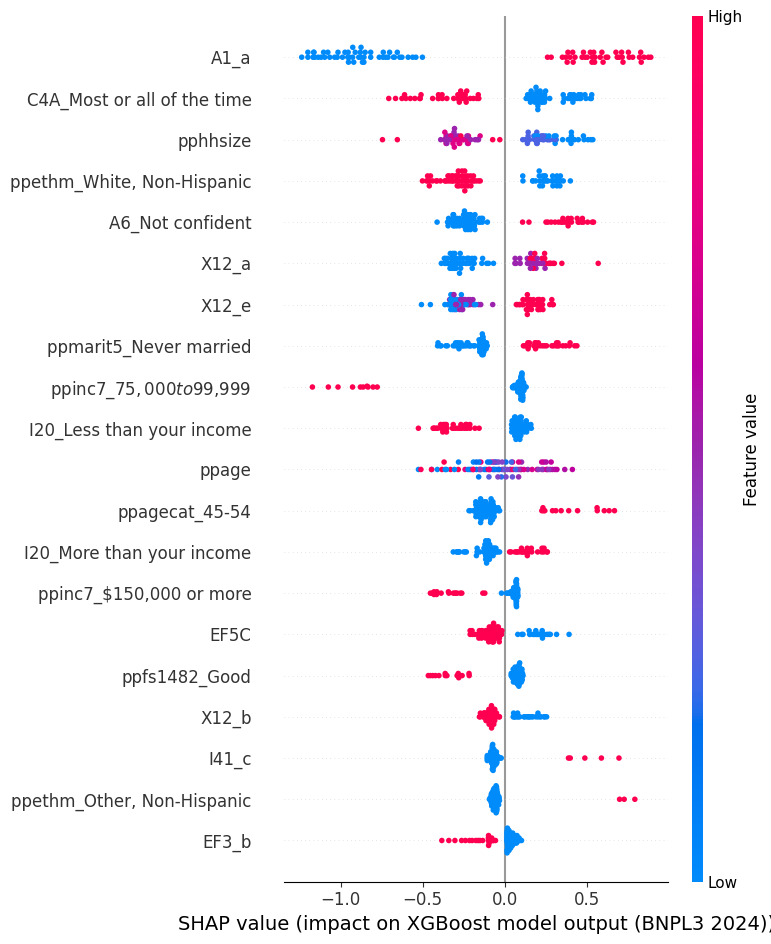

<Figure size 640x480 with 0 Axes>

In [ ]:
explainer = shap.TreeExplainer(xgb_fit)
shap_values = explainer.shap_values(X_test_res)

plt.figure(figsize=(35, 12))
shap.summary_plot(shap_values, X_test_res, show=False)

plt.subplots_adjust(left=0.35, right=0.95)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("SHAP value (impact on XGBoost model output (BNPL3 2024))", fontsize=14)

plt.show()

# save
plt.savefig('img/shap_BNPL3_2024.png', dpi=300, bbox_inches='tight')